In [290]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = 'whitegrid')

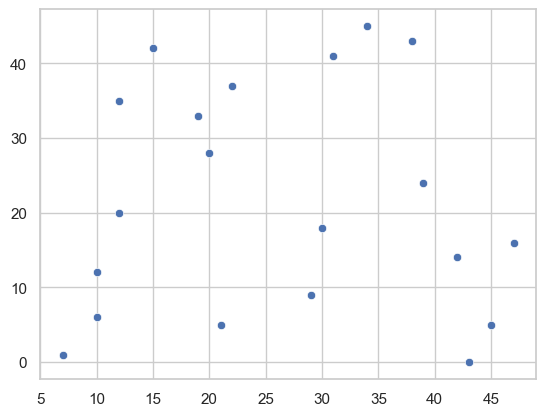

In [291]:

num_points = 20
x = np.random.randint(low = 0, high = 50, size = num_points)
y = np.random.randint(low = 0, high = 50, size = num_points)

sns.scatterplot(x = x, y = y)
plt.show()

Only points on the convex hull can be included on the voronoi diagram

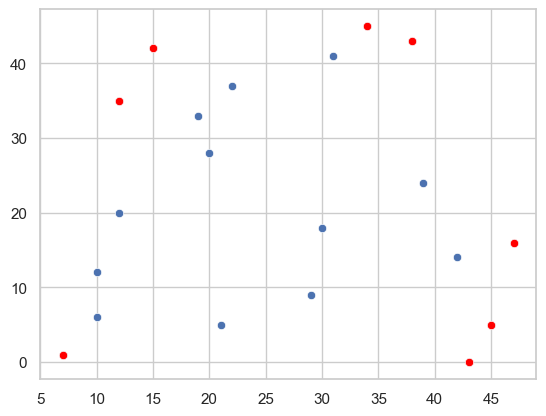

In [292]:
convex_hull = sp.spatial.ConvexHull(np.column_stack((x,y)))
sns.scatterplot(x = x, y = y)
sns.scatterplot(x = x[convex_hull.vertices], y = y[convex_hull.vertices], color = 'red')
plt.show()

In [293]:
x = x[convex_hull.vertices]
y = y[convex_hull.vertices]

# Lifting Points onto Paraboloid

In [294]:
z = x**2 + y**2
z

array([3181, 1989, 1369,   50, 1849, 2050, 2465, 3293], dtype=int32)

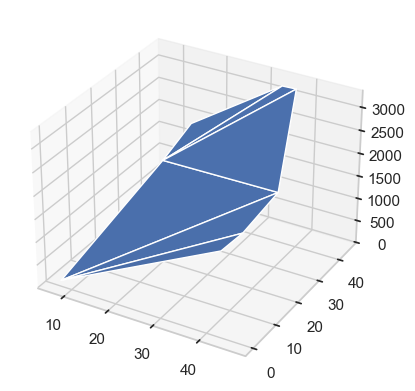

In [295]:
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})

ax.plot_trisurf(x,y,z)

In [296]:
convex_3d = sp.spatial.ConvexHull(points = np.column_stack((x,y,z)))

Equations are the planes of the convex hull described as the components of the normal vector + the offset, or 

$ \vec{n} + b $

In [297]:
convex_3d.equations[0]

array([-0.78859819, -0.614715  ,  0.01543903,  5.36295068])

We can determine which faces are pointing upwards by only keeping the faces that have 
$ \vec{n} \cdot \hat{k} > 0 $

In [298]:
k = [0, 0, 1] # k-hat, or the z basis vector
valid = np.empty(len(convex_3d.equations), dtype = bool)

for i, eq in enumerate(convex_3d.equations):
    
    if np.dot(k, eq[:-1]) > 0:
        valid[i] = True
        
    else:
        valid[i] = False
        

# Creating a class to organize adjacency between convex hull faces (simplices), circumcenters, and points before Farthest-Delaunay Triangulation Projection

In [299]:
class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        
        self.adjacency = []
        self.simplices = []
        self.circumcenters = []


In [300]:
points = []
for x_i, y_i in zip(x, y):
    points.append(Point(x_i, y_i))

In [301]:
def plot_simplex(x, y, simplex):
    line1 = [simplex[0], simplex[1]]
    line2 = [simplex[1], simplex[2]]
    line3 = [simplex[0], simplex[2]]
    
    for line in [line1, line2, line3]:
        plt.plot(x[line], y[line])

In [302]:
def set_adjacency(points, simplex):
    s = simplex.copy()
    shift = 1
    
    for row in simplex:
        neighbors = np.roll(s, shift)[1:]
        
        for n in neighbors:
            if n not in points[row].adjacency:
                points[row].adjacency.append(n)
        
        shift += 1

In [303]:
def get_circumcenter(x, y, simplex):
    x1, x2, x3 = x[simplex[0]], x[simplex[1]], x[simplex[2]]
    y1, y2, y3 = y[simplex[0]], y[simplex[1]], y[simplex[2]]
    
    d = 2 * (x1 * (y2 - y3) + x2 * (y3 - y1) + x3 * (y1 - y2))

    a_sq = x1**2 + y1**2
    b_sq = x2**2 + y2**2
    c_sq = x3**2 + y3**2

    u = (a_sq * (y2 - y3) + b_sq * (y3 - y1) + c_sq * (y1 - y2)) / d
    v = (a_sq * (x3 - x2) + b_sq * (x1 - x3) + c_sq * (x2 - x1)) / d
    
    return u, v

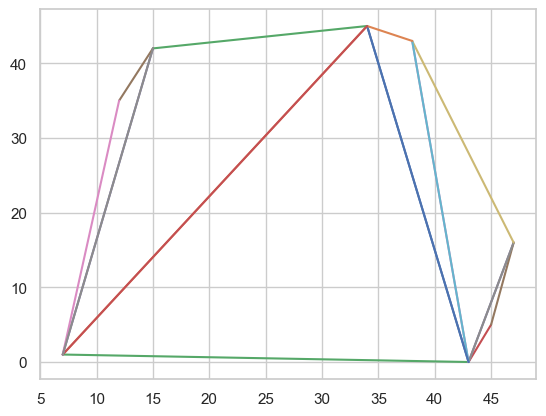

In [304]:
ax = plt.subplot()
for i, simplex in enumerate(convex_3d.simplices[valid]):
    plot_simplex(x,y, simplex)
    set_adjacency(points, simplex)
    cc = get_circumcenter(x, y, simplex)
    
    for point in simplex:
        points[point].circumcenters.append(cc)
        points[point].simplices.append(simplex)
xlim = ax.get_xlim()
ylim = ax.get_ylim()

In [305]:
points[0].circumcenters

[(np.float64(25.539106145251395), np.float64(19.907821229050278)),
 (np.float64(23.77777777777778), np.float64(19.555555555555557)),
 (np.float64(28.513245033112582), np.float64(18.082781456953644))]

In [306]:
points[1].circumcenters

[(np.float64(28.513245033112582), np.float64(18.082781456953644)),
 (np.float64(88.41044776119404), np.float64(6.395522388059701))]